(mmm_placebo_check)=
# Placebo Channels: How Much Credit Does the Model Give to Nothing?

A marketing mix model is fitted against the same outcome it is later asked to explain. Whatever the intercept, the seasonality and the controls leave unexplained has to go somewhere, and every channel in the model is a candidate. So a channel's contribution is never purely its effect: part of it is the share of leftover variation that any plausible-looking spend series would have collected.

A **placebo channel** measures that part directly. Take a real spend series, destroy its alignment with the outcome, put it back in the model as an ordinary channel, and refit. It cannot have caused anything, so whatever contribution the model still assigns to it is the floor: the amount of credit this model, on this data, hands out for nothing. Contributions worth acting on have to clear that floor.

This is the *negative control* idea from epidemiology ([Lipsitch, Tchetgen Tchetgen & Cohen, 2010](https://pubmed.ncbi.nlm.nih.gov/20335814/)) applied to attribution: an exposure known to have no effect, carried through the identical analysis, tells you what the analysis produces in the absence of an effect.

The construction itself is a few lines of NumPy, so this notebook is the whole recipe rather than an API to import.


## Prepare Notebook

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import xarray as xr
from pymc.model.transform.conditioning import do
from pymc_extras.prior import Prior

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.mmm import MMM
from pymc_marketing.mmm.placebo import (
    add_placebo_channel,
    contribution_share,
    placebo_correlation,
    summarize_placebo_contribution,
)
from pymc_marketing.paths import data_dir
from pymc_marketing.special_priors import LaplacePrior, LogNormalPrior

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

In [2]:
seed: int = sum(map(ord, "mmm_placebo"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## Data

We reuse the simulated data set and the model specification of the {ref}`mmm_multidimensional_example`: one product, two geos, two channels, two event controls. That notebook describes the data as noisy and low-signal, and asks whether the model can parse the signal out of it. The placebo channel turns that question into a number.


In [3]:
data_df = pd.read_csv(
    data_dir / "mmm_multidimensional_example.csv", parse_dates=["date"]
)

data_df.head()

,date,geo,x1,x2,event_1,event_2,y
0,2022-06-06,geo_a,5527.640078,0.000000,0,0,2647.596355
1,2022-06-06,geo_b,8849.257500,8063.918386,0,0,682.406280
2,2022-06-13,geo_a,6692.655692,0.000000,0,0,5020.823907
3,2022-06-13,geo_b,9073.817994,9354.014585,0,0,3753.104897
4,2022-06-20,geo_a,7124.016733,0.000000,0,0,6184.322132


## Building the placebo channel

We copy channel `x1` and break its alignment with the outcome by rolling it forward by a random offset, within each geo. Two properties matter:

- **Circular shift keeps the shape of the series.** The flighting pattern, the autocorrelation and the seasonality of spend all survive; only the timing relative to sales is destroyed. That makes it a *hard* placebo: it looks exactly like a media series in every respect the model can exploit, except the one that matters.
- **A random permutation is the easier variant.** It preserves only the marginal distribution of spend, so it is visibly not a media series. Use it as a second, weaker check, or when the shift happens to leave the placebo correlated with the original.

We keep the shift within a geo so the placebo stays a plausible series for that market.

In [4]:
data_df, placebo = add_placebo_channel(data_df, "x1", group_column="geo", seed=rng)
channels = ["x1", "x2", placebo]

print(f"placebo column: {placebo}")
print(
    "correlation with the real channel: "
    f"{placebo_correlation(data_df, 'x1', placebo):.3f}"
)

placebo column: x1_placebo
correlation with the real channel: 0.082


The correlation with the real channel is small, which is what we want: the placebo carries the *look* of a media series without carrying its timing. Check this number every time. A shift that happens to land near the period of a strongly seasonal series can leave the placebo highly correlated with the original, and then the two channels are competing for the same credit for a different reason.


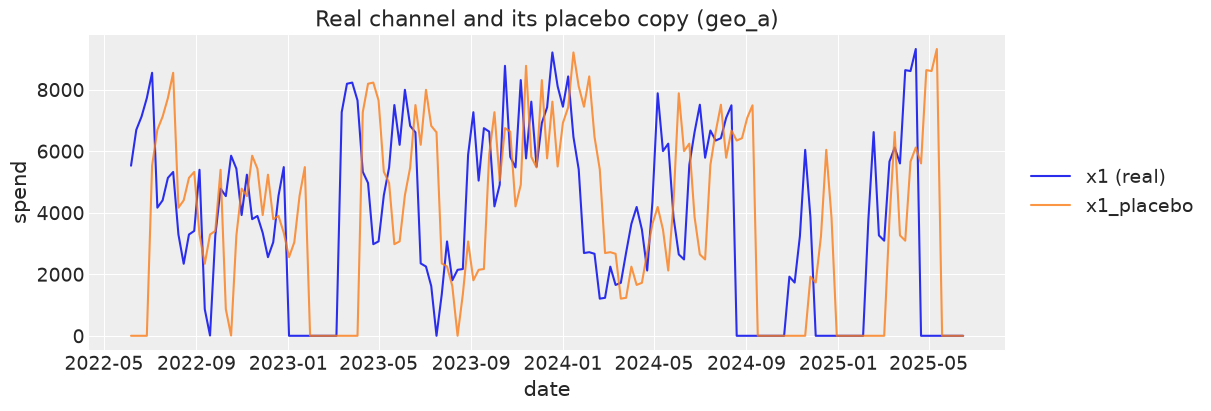

In [5]:
geo = "geo_a"
subset = data_df[data_df["geo"] == geo]

fig, ax = plt.subplots(figsize=(12, 4), layout="constrained")
ax.plot(subset["date"], subset["x1"], label="x1 (real)", color="C0")
ax.plot(subset["date"], subset[placebo], label=placebo, color="C1", alpha=0.8)
ax.set(
    title=f"Real channel and its placebo copy ({geo})", xlabel="date", ylabel="spend"
)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5));

## Model

The specification is the one from the {ref}`mmm_multidimensional_example`, with a single change: the placebo enters `channel_columns` as an ordinary channel. It gets the same adstock, the same saturation and the same priors as the real channels. Nothing marks it out to the model, which is the point.


In [6]:
def build_mmm(channel_columns: list[str]) -> MMM:
    beta_prior = LogNormalPrior(
        mean=Prior("Gamma", mu=0.25, sigma=0.10, dims="channel"),
        std=Prior("Exponential", scale=0.10, dims="channel"),
        dims=("channel", "geo"),
        centered=False,
    )
    saturation = LogisticSaturation(
        priors={
            "beta": beta_prior,
            "lam": Prior("Gamma", mu=0.5, sigma=0.25, dims="channel"),
        }
    )
    adstock = GeometricAdstock(
        priors={"alpha": Prior("Beta", alpha=2, beta=5, dims=("geo", "channel"))},
        l_max=8,
    )
    model_config = {
        "intercept": Prior("Gamma", mu=0.5, sigma=0.25, dims="geo"),
        "gamma_control": Prior("Normal", mu=0, sigma=0.5, dims="control"),
        "gamma_fourier": LaplacePrior(
            mu=0,
            b=Prior("HalfNormal", sigma=0.2),
            dims=("geo", "fourier_mode"),
            centered=False,
        ),
        "likelihood": Prior(
            "TruncatedNormal",
            lower=0,
            sigma=Prior("HalfNormal", sigma=1.5),
            dims=("date", "geo"),
        ),
    }
    return MMM(
        date_column="date",
        target_column="y",
        channel_columns=channel_columns,
        control_columns=["event_1", "event_2"],
        dims=("geo",),
        scaling={
            "channel": {"method": "max", "dims": ()},
            "target": {"method": "max", "dims": ()},
        },
        adstock=adstock,
        saturation=saturation,
        yearly_seasonality=2,
        model_config=model_config,
    )


def fit_mmm(
    X: pd.DataFrame,
    y: pd.Series,
    rng: np.random.Generator,
    channel_columns: list[str] | None = None,
) -> MMM:
    mmm = build_mmm(channel_columns or channels)
    mmm.build_model(X=X, y=y)
    # contributions on the original scale are comparable across geos
    mmm.add_original_scale_contribution_variable(var=["channel_contribution"])
    mmm.fit(
        X=X,
        y=y,
        chains=4,
        draws=1000,
        tune=1000,
        target_accept=0.95,
        nuts_sampler="nutpie",
        random_seed=rng,
        progressbar=False,
    )
    return mmm

In [7]:
X = data_df.drop(columns=["y"])
y = data_df["y"]

mmm = fit_mmm(X, y, rng)

print(f"divergences: {int(mmm.idata.sample_stats.diverging.sum())}")

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta_mean, saturation_beta_std, saturation_beta_log_offset, gamma_fourier_b, gamma_fourier_sigma, gamma_fourier_offset, gamma_control, y_sigma, intercept_contribution]


divergences: 0


## The baseline: what the placebo actually displaced

The same model and the same data, fitted with the two real channels only. Comparing the two runs separates the arithmetic from the finding: how much of each real channel's share the placebo took, rather than how much three-way division cost it.

In [8]:
mmm_baseline = fit_mmm(X, y, rng, channel_columns=["x1", "x2"])

print(f"divergences: {int(mmm_baseline.idata.sample_stats.diverging.sum())}")

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta_mean, saturation_beta_std, saturation_beta_log_offset, gamma_fourier_b, gamma_fourier_sigma, gamma_fourier_offset, gamma_control, y_sigma, intercept_contribution]


divergences: 0


## Reading the result

For each channel we take its total absolute contribution across dates and geos, express it as a share of the total across channels, and keep the whole posterior rather than a point estimate. Two quantities come out of it:

- the **share** the model assigns to the placebo, which is the floor;
- for every real channel, **P(> placebo)**: the fraction of posterior draws in which that channel's share exceeds the placebo's. This is the number to act on. It turns "this channel looks important" into "this channel beats a series that cannot have caused anything, in this fraction of the posterior".

One asymmetry to keep in view while reading the table. The placebo here is built from `x1`, so it competes hardest with `x1`: same marginal, same flighting, same autocorrelation, the same scale entering adstock and saturation. The low correlation between the two does not remove that, because the competition is over the shape of credit the model can allocate rather than over pointwise agreement. **P(> placebo)** for `x1` is therefore the least favourable comparison in the table, and `x2` is being measured against a placebo that was not cut from it. For a real analysis, build the placebo from a channel other than the one being interrogated, or build one per channel and read each against its own.


In [9]:
summary = summarize_placebo_contribution(
    mmm.idata.posterior["channel_contribution_original_scale"],
    mmm_baseline.idata.posterior["channel_contribution_original_scale"],
    placebo,
)
summary.round(3)

,share,hdi_low,hdi_high,prob_exceeds_placebo,share_without_placebo,lost,dilution_alone
channel,,,,,,,
x1,0.457,0.129,0.756,0.792,0.595,0.137,0.141
x2,0.305,0.039,0.572,0.625,0.405,0.100,0.096
x1_placebo,0.238,0.016,0.486,NaN,NaN,NaN,NaN


In [10]:
first, second = [ch for ch in channels if ch != placebo]
without = summary["share_without_placebo"]
with_ = summary["share"]

print(f"{first} : {second} without the placebo  {without[first] / without[second]:.3f}")
print(f"{first} : {second} with the placebo     {with_[first] / with_[second]:.3f}")

x1 : x2 without the placebo  1.467
x1 : x2 with the placebo     1.500


Read `lost` against `dilution alone`. `lost` is what each real channel actually gave up when the placebo entered the model; `dilution alone` is what it would have given up if the placebo had simply taken its share out of the total and left the real channels' standing relative to each other untouched.

On this data the two columns agree closely and the ratio printed above barely moves: the placebo took a nearly proportional cut from both real channels rather than singling one out.

How closely is worth stating as a measured number rather than read off one run, because it is the load-bearing claim here. Repeating both fits at three sampling seeds, `lost` minus `dilution alone` stays between -0.006 and -0.004 for `x1` and between +0.004 and +0.006 for `x2`, and the ratio shifts by +0.03 to +0.05. The residual is small but it is consistently signed: `x1` gives up slightly **less** than proportional dilution would take, not more. An earlier version of this notebook reported the two columns as agreeing to three decimals with the ratio pinned; that was one seed on one sampler version, and it did not survive an upgrade of pymc and pytensor with nothing else changed. That is worth stating plainly, because it is the opposite of what the first table might suggest on its own. The placebo did not reveal that `x1` in particular was overstated; if anything `x1` is the one it takes slightly less from. It lowered the level of both channels by close to the same factor, which says the over-attribution this model commits here is not channel-specific, it is the whole allocation being generous, and both channels inherit it in proportion.

That distinction matters for what you do next. A channel that loses appreciably more than `dilution alone` was carrying credit a shifted copy of a spend series could take from it specifically, and that is a finding about that channel. A channel that loses only the dilution, as both do here, tells you instead that the floor is a property of the model and the data rather than of any one line in the media plan.

This column pair is also the number a stakeholder actually asks for. Not "how much does the model give to nothing", but "how much of *this channel's* number was that".

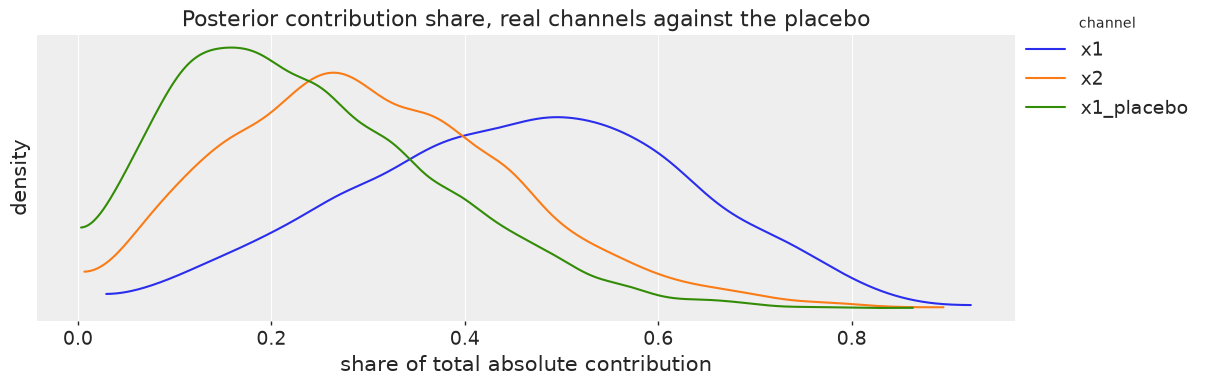

In [11]:
share = contribution_share(mmm.idata.posterior["channel_contribution_original_scale"])

pc = az.plot_dist(
    share.rename("contribution_share").to_dataset(),
    kind="kde",
    aes={"color": ["channel"]},
    cols=None,
    visuals={
        "credible_interval": False,
        "point_estimate": False,
        "point_estimate_text": False,
        "title": False,
    },
)
pc.add_legend("channel")

ax = pc.viz["figure"].item().axes[0]
ax.set(
    title="Posterior contribution share, real channels against the placebo",
    xlabel="share of total absolute contribution",
    ylabel="density",
);

The placebo is not a thin spike at zero. It collects a substantial share of the credit, and the real channels' posteriors overlap it heavily: neither of them clears the floor with much confidence. Given how the multidimensional example describes this data, deliberately noisy and low signal, that is the honest read, and it is the read the contribution plot alone does not give you. A channel contribution chart without a placebo shows two bars of respectable size and says nothing about how large a bar this model produces for a series with no relationship to sales at all.

Note also what the placebo's floor is made of. `saturation_beta` is strictly positive here, so *every* channel contributes something by construction, and a placebo cannot come back at exactly zero in this parameterisation. That is not a flaw in the check, it is the quantity being measured, and it is why **P(> placebo)** rather than the raw share is the number to read.

The `np.abs` in `contribution_share` is a no-op under this specification for the same reason. Keep it in mind if you reuse the recipe somewhere `saturation_beta` can go negative: taking the absolute value would score a large negative contribution as if it were a large positive one, and there you want the signed sum, or a separate treatment of sign.

One thing this table cannot tell you on its own. Shares are compositional, so they are forced to sum to one: going from two channels to three shrinks every share by arithmetic, whatever the third channel is. So a reader cannot yet separate *the placebo revealed that `x1` was overstated* from *three channels divide the same pie three ways*. That takes one more fit.

## Can this check fail?

A diagnostic that always reassures is not a diagnostic. Two runs test that, and they are not equally strong.

The first is a **negative control on the target**: within each geo, permute `y` across dates. Spend keeps its flighting and autocorrelation, each geo keeps its level and its marginal distribution of sales, and only the pairing between a date's spend and that date's sales is destroyed. With no effect left to find, every real channel should sit at **P(> placebo)** near 0.5.

Be clear about how much that establishes. Permuting the target destroys the seasonality and the trend along with the spend-to-sales pairing, and once that is gone the three channels are exchangeable as far as the model is concerned. A statistic near 0.5 there follows largely from symmetry, so almost any share comparison would pass it. It is a sanity check on the plumbing, not evidence that the statistic discriminates.

The second run is the one that carries the weight: a **positive control on data whose answer is known**, built below.

In [12]:
y_scrambled = (
    y.groupby(data_df["geo"], sort=False)
    .transform(lambda s: rng.permutation(s.to_numpy()))
    .rename("y")
)

mmm_null = fit_mmm(X, y_scrambled, rng)
mmm_null_baseline = fit_mmm(X, y_scrambled, rng, channel_columns=["x1", "x2"])

print(f"divergences: {int(mmm_null.idata.sample_stats.diverging.sum())}")
summarize_placebo_contribution(
    mmm_null.idata.posterior["channel_contribution_original_scale"],
    mmm_null_baseline.idata.posterior["channel_contribution_original_scale"],
    placebo,
).round(3)

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta_mean, saturation_beta_std, saturation_beta_log_offset, gamma_fourier_b, gamma_fourier_sigma, gamma_fourier_offset, gamma_control, y_sigma, intercept_contribution]


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta_mean, saturation_beta_std, saturation_beta_log_offset, gamma_fourier_b, gamma_fourier_sigma, gamma_fourier_offset, gamma_control, y_sigma, intercept_contribution]


divergences: 0


,share,hdi_low,hdi_high,prob_exceeds_placebo,share_without_placebo,lost,dilution_alone
channel,,,,,,,
x1_placebo,0.357,0.043,0.663,NaN,NaN,NaN,NaN
x1,0.353,0.044,0.658,0.494,0.546,0.192,0.195
x2,0.290,0.033,0.581,0.414,0.454,0.164,0.162


On the scrambled target the real channels sit at **P(> placebo)** near or below a coin flip, which is what "no evidence of an effect" looks like on this scale. Take it for what it is worth: the recipe does not manufacture evidence out of a target with none left in it, and the plumbing works. It does not show that the statistic can tell a real channel from a placebo, because on this data nothing distinguishes them. That is what the next section is for.

## The positive control

The simulated data set ships with the parameters that generated it, in `mmm_multidimensional_example_true_parameters.nc` alongside the CSV. That makes a stronger test available: generate a target whose channel effects we choose, with the placebo's effect set to exactly zero, and check that the recipe recovers the ordering we put in.

We keep the real spend series, the controls and the seasonality. Through `pm.do` we fix `saturation_beta`, `saturation_lam` and `adstock_alpha` to the true values, scale the real channels' betas up so the signal is unambiguous, set the placebo's beta to zero, and draw one target from the prior predictive with a small observation noise. The generating truth is then known exactly: `x1` twice the effect of `x2`, and nothing at all from the placebo.

In [13]:
true_params = xr.open_dataset(
    data_dir / "mmm_multidimensional_example_true_parameters.nc"
)
true_beta = true_params["saturation_beta"].transpose("channel", "geo").values
true_lam = true_params["saturation_lam"].values
true_alpha = true_params["adstock_alpha"].transpose("geo", "channel").values

AMPLIFY = 4.0  # lift the real channels clear of the noise; the ordering is unchanged

# the placebo gets a zero beta, and otherwise the transform parameters of the
# channel it was copied from, so it is only its *effect* that is absent
beta_control = np.vstack([AMPLIFY * true_beta, np.zeros((1, true_beta.shape[1]))])
lam_control = np.concatenate([true_lam, true_lam[:1]])
alpha_control = np.concatenate([true_alpha, true_alpha[:, :1]], axis=1)

control_model = do(
    mmm.model,
    {
        "saturation_beta": beta_control,
        "saturation_lam": lam_control,
        "adstock_alpha": alpha_control,
        "y_sigma": np.float64(0.02),
    },
)
with control_model:
    generated = pm.sample_prior_predictive(draws=1, random_seed=20260902)

# the share we put in, for comparison with the share we get back out
true_contribution = generated.prior["channel_contribution"].isel(chain=0, draw=0)
true_total = np.abs(true_contribution).sum(
    dim=[d for d in true_contribution.dims if d != "channel"]
)
true_share = (true_total / true_total.sum()).to_pandas()
true_share.round(3)

channel
x1            0.663
x2            0.337
x1_placebo    0.000
Name: channel_contribution, dtype: float64

In [14]:
target_scale = mmm.get_scales_as_xarray()["target_scale"]
y_control = (
    (generated.prior_predictive["y"].isel(chain=0, draw=0) * target_scale)
    .to_dataframe(name="y")
    .reset_index()
)
y_control = (
    X[["date", "geo"]].merge(y_control, on=["date", "geo"], how="left")["y"].rename("y")
)

mmm_control = fit_mmm(X, y_control, rng)
mmm_control_baseline = fit_mmm(X, y_control, rng, channel_columns=["x1", "x2"])

print(f"divergences: {int(mmm_control.idata.sample_stats.diverging.sum())}")
summarize_placebo_contribution(
    mmm_control.idata.posterior["channel_contribution_original_scale"],
    mmm_control_baseline.idata.posterior["channel_contribution_original_scale"],
    placebo,
).round(3)

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta_mean, saturation_beta_std, saturation_beta_log_offset, gamma_fourier_b, gamma_fourier_sigma, gamma_fourier_offset, gamma_control, y_sigma, intercept_contribution]


NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta_mean, saturation_beta_std, saturation_beta_log_offset, gamma_fourier_b, gamma_fourier_sigma, gamma_fourier_offset, gamma_control, y_sigma, intercept_contribution]


divergences: 1


,share,hdi_low,hdi_high,prob_exceeds_placebo,share_without_placebo,lost,dilution_alone
channel,,,,,,,
x1,0.644,0.617,0.667,1.0,0.659,0.015,0.013
x2,0.337,0.319,0.355,1.0,0.341,0.004,0.007
x1_placebo,0.019,0.000,0.041,NaN,NaN,NaN,NaN


This is the run that shows the check discriminates. The generating truth had `x1` at twice the effect of `x2` and the placebo at nothing; the recipe puts the two real channels above the placebo with **P(> placebo)** near one, in that order, and leaves the placebo with the small residual share that a strictly positive `saturation_beta` guarantees it.

Put beside the first table, that is the calibration. On the real target neither channel reaches anything like this separation, and it is now clear that the reason is the data rather than a statistic incapable of separating anything.

## What this does and does not tell you

**It tells you** how much contribution your model hands to a series that cannot have caused anything, under your priors, your controls, your seasonality and your data. That floor is model-specific and data-specific, which is why it has to be measured rather than assumed.

**It does not tell you** that a channel clearing the placebo is causal. A placebo landing low rules out one failure mode, the indiscriminate attribution of leftover variation, and leaves the others untouched: confounding, reverse causality, and selection into spend all survive a placebo check comfortably. Necessary, not sufficient.

### When to run it

Once per model specification, before any contribution number leaves the analysis, and again whenever that specification changes: new controls, different seasonality, different priors, a different adstock or saturation. The floor moves with the model and not only with the data, so a floor measured on last quarter's specification says little about this one. The cost is one extra channel in the fit, which is small next to the cost of acting on a contribution that a shifted copy of another channel would have matched.

### How many placebos

One placebo gives you a floor, but a single floor is one draw from a noisy quantity: the offset is random, and another offset gives another placebo. Three to five, built from different source channels and different offsets, turn the floor into a range.

**Run them as separate fits, one placebo each.** Putting five placebos into a single model is not the same experiment and does not give a comparable answer: shares are compositional, so with five placebos and two real channels each placebo takes roughly a seventh of the total by arithmetic alone and the floor comes out artificially low. Only the separate-refit version produces floors comparable to each other and to the single-placebo table above. The cost is one fit per placebo rather than one fit in total.

Read the highest of them rather than the average. The question is how much credit this model *can* hand out for nothing, not how much it happened to hand out once. If the placebos disagree widely, that spread is itself the result: the attribution is unstable across equally uninformative inputs, and no single contribution number from that model deserves much weight.

Two rules for building them:

- Build each placebo from a **real** spend series rather than random noise. A noise channel is trivially rejected and tells you nothing about how the model treats series that look like media.
- Always check the correlation between a placebo and its source. If the shift leaves them correlated, use the permutation variant, or a different offset.


In [15]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor,nutpie

Last updated: Thu, 03 Sep 2026

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.16.1

pymc_marketing: 1.1.0
pytensor      : 3.2.4
nutpie        : 0.16.11

arviz         : 1.2.0
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 2.3.3
pymc          : 6.2.0
pymc_extras   : 0.14.0
pymc_marketing: 1.1.0
xarray        : 2026.4.0

Watermark: 2.6.0

